In [70]:
import pandas as pd
from matplotlib import pyplot as plt

from trainer.src.influx_reader import load_data

# EDA

In [49]:
df = load_data()

In [3]:
df.shape

(43076, 11)

In [4]:
df.head()

,time,device_id,current,failure,humidity,load,pressure,rpm,temperature,vibration,wear
0,2026-08-05T12:54:00.420321+00:00,motor_000,15.06,0,46.5,0.574,6.08,2189.0,59.59,0.50,0.0001
1,2026-08-05T12:54:01.563675+00:00,motor_000,15.82,0,49.1,0.588,6.05,2218.0,61.01,0.55,0.0003
2,2026-08-05T12:54:02.567700+00:00,motor_000,14.97,0,45.0,0.577,6.03,2254.0,59.03,0.59,0.0004
3,2026-08-05T12:54:03.571979+00:00,motor_000,15.46,0,45.7,0.597,5.97,2195.0,61.22,0.62,0.0006
4,2026-08-05T12:54:04.578218+00:00,motor_000,15.90,0,51.1,0.602,6.06,2212.0,62.51,0.60,0.0007


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43076 entries, 0 to 43075
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         43076 non-null  str    
 1   device_id    43076 non-null  str    
 2   current      43076 non-null  float64
 3   failure      43076 non-null  int64  
 4   humidity     43076 non-null  float64
 5   load         43076 non-null  float64
 6   pressure     43076 non-null  float64
 7   rpm          43076 non-null  float64
 8   temperature  43076 non-null  float64
 9   vibration    43076 non-null  float64
 10  wear         43076 non-null  float64
dtypes: float64(8), int64(1), str(2)
memory usage: 3.6 MB


In [6]:
df.describe()

,current,failure,humidity,load,pressure,rpm,temperature,vibration,wear
count,43076.000000,43076.000000,43076.000000,43076.000000,43076.000000,43076.000000,43076.000000,43076.000000,43076.000000
mean,15.296390,0.003830,45.005567,0.565368,5.952253,2170.799308,60.513432,0.620635,0.021751
std,4.219282,0.061773,3.972283,0.228189,0.251704,298.700536,8.642262,0.357221,0.016687
min,1.230000,0.000000,28.200000,0.200000,1.450000,120.000000,44.690000,0.250000,0.000100
25%,12.020000,0.000000,42.300000,0.384000,5.930000,1957.000000,53.930000,0.500000,0.008500
50%,14.820000,0.000000,45.000000,0.537000,5.970000,2143.000000,59.370000,0.590000,0.018100
75%,18.590000,0.000000,47.700000,0.746000,6.000000,2393.000000,66.840000,0.700000,0.031400
max,24.750000,1.000000,61.600000,1.000000,6.170000,2761.000000,113.350000,6.940000,0.094400


In [7]:
df["device_id"].nunique()

4

In [8]:
df["device_id"].value_counts()

device_id
motor_000    11065
motor_001    10873
motor_002    10653
motor_003    10485
Name: count, dtype: int64

In [9]:
df.groupby("device_id")["time"].agg(["min", "max", "count"])

,min,max,count
device_id,,,
motor_000,2026-08-05T12:54:00.420321+00:00,2026-08-05T18:30:50.857879+00:00,11065
motor_001,2026-08-05T12:54:00.545774+00:00,2026-08-05T18:30:50.857862+00:00,10873
motor_002,2026-08-05T12:54:00.431630+00:00,2026-08-05T18:30:50.856503+00:00,10653
motor_003,2026-08-05T12:54:00.265644+00:00,2026-08-05T18:30:50.857831+00:00,10485


# Some plots

In [16]:
features = df.columns.drop('time').drop('device_id')
features

Index(['current', 'failure', 'humidity', 'load', 'pressure', 'rpm',
       'temperature', 'vibration', 'wear'],
      dtype='str')

In [10]:
device = "motor_001"

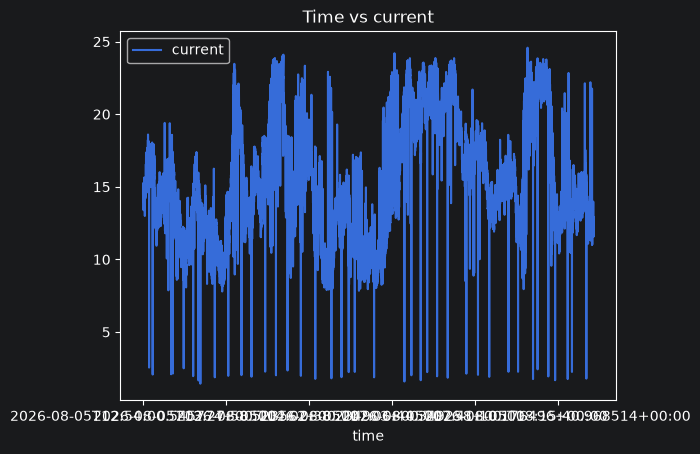

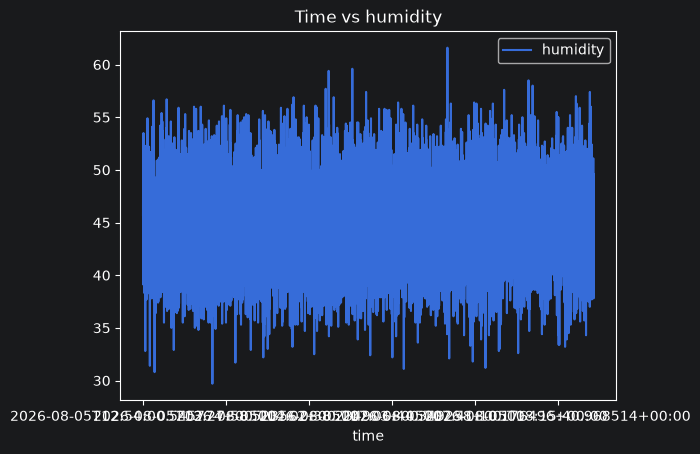

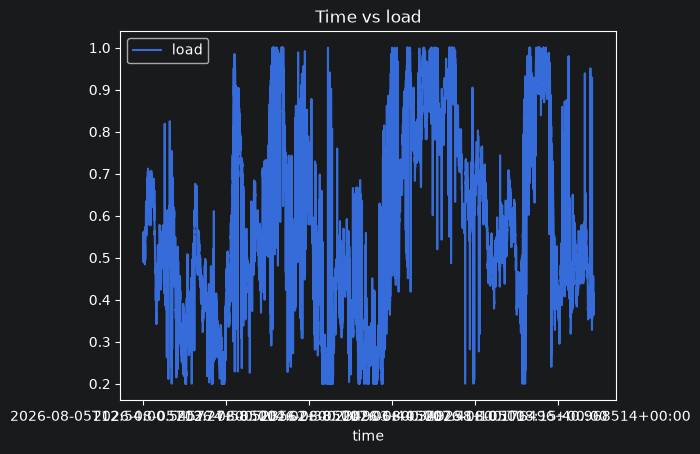

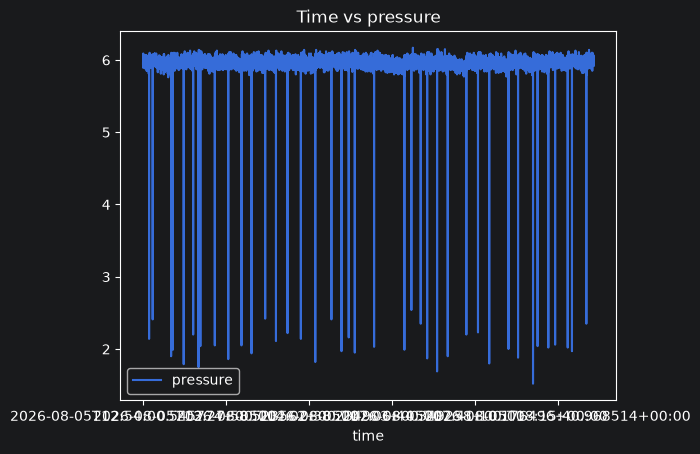

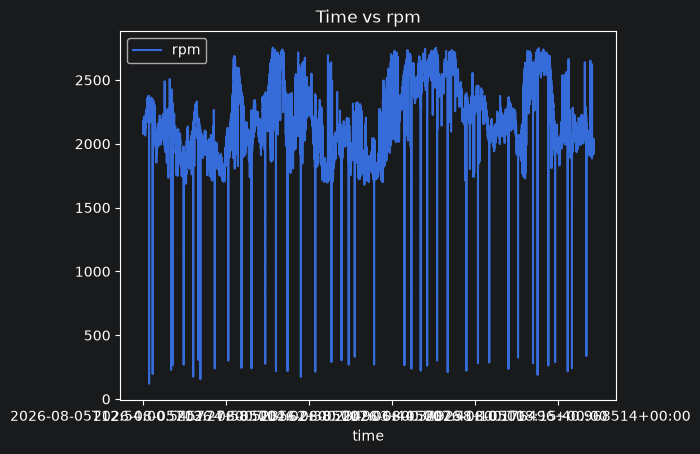

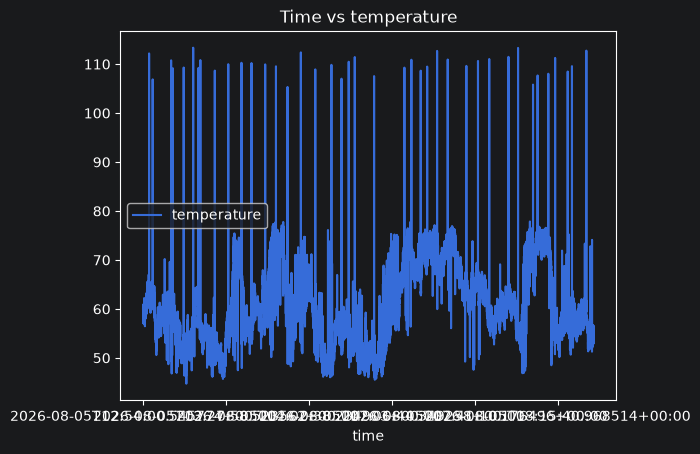

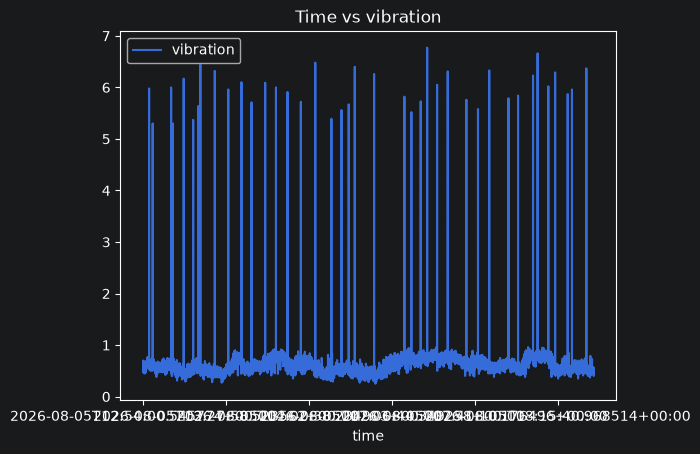

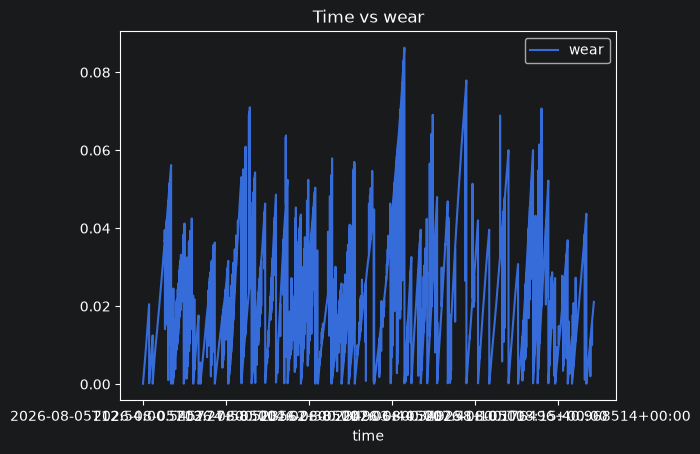

In [56]:
subset = df[df['device_id'] == device].drop(columns='device_id')

for feature in features:
    subset.plot(x='time',
                y=feature,
                title=f"Time vs {feature}")

looks like spikes in some features lead to spikes in failure, lets see

In [58]:
# time as index for faster plots
subset = subset.set_index('time')
subset.index = pd.to_datetime(subset.index)

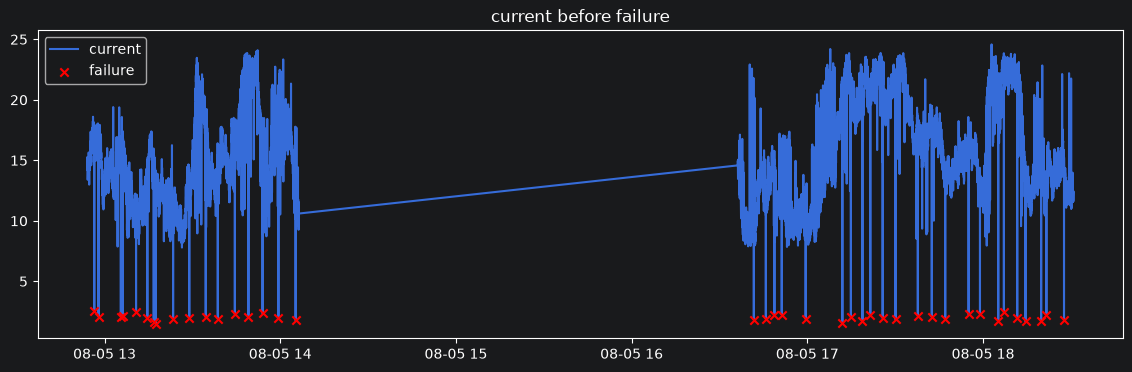

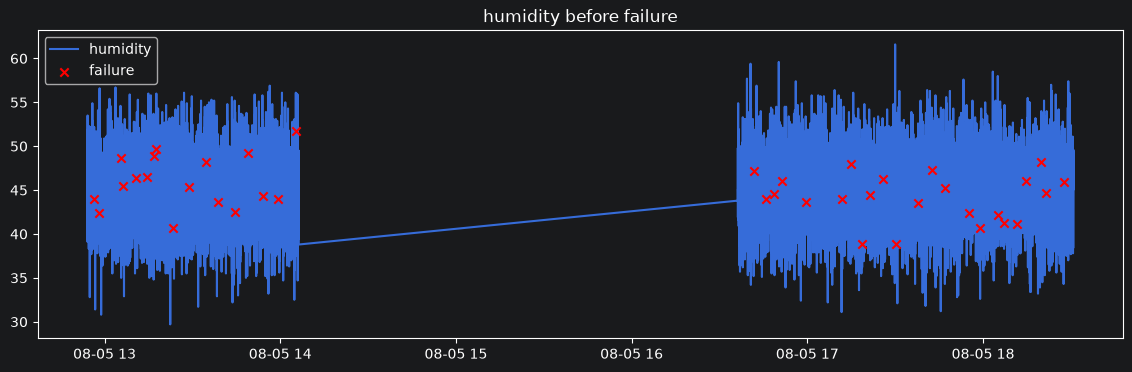

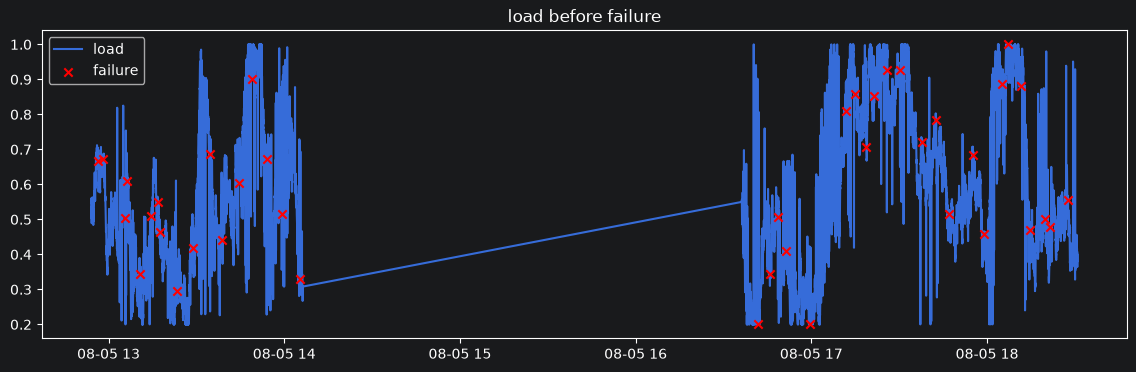

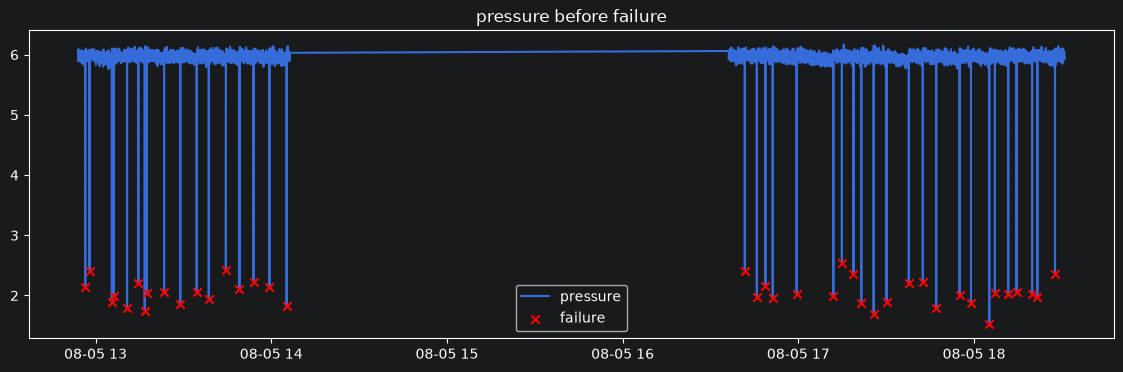

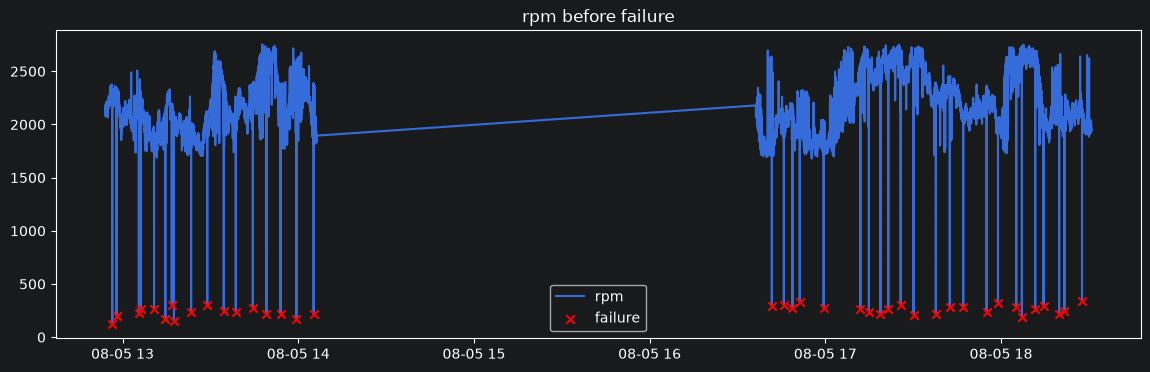

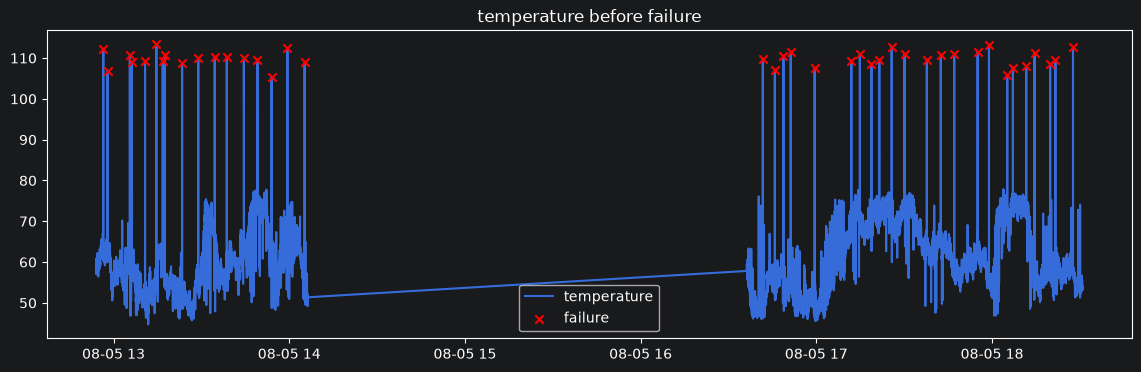

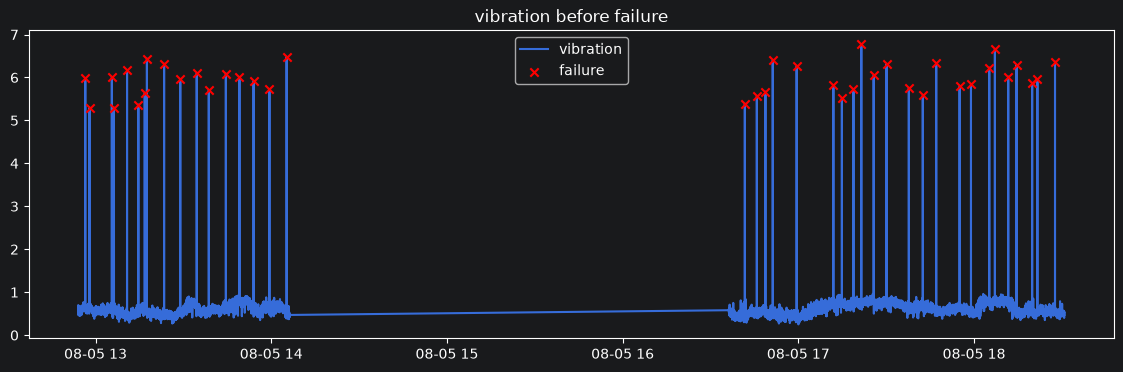

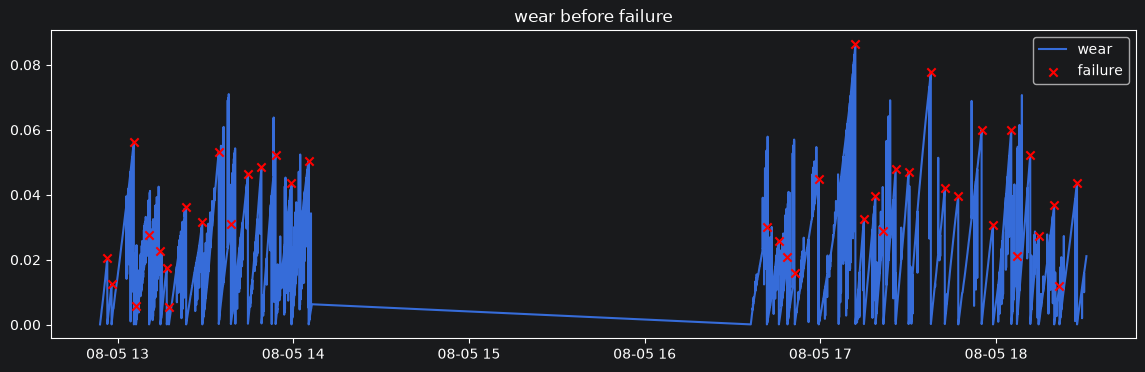

In [69]:
failure_points = subset[subset["failure"] == 1]

for feature in features:
    plt.figure(figsize=(14, 4))

    plt.plot(
        subset.index,
        subset[feature],
        label=feature,
        zorder=1
    )

    plt.scatter(
        failure_points.index,
        failure_points[feature],
        marker='x',
        label='failure',
        color='red',
        zorder=10
    )

    plt.title(f"{feature} before failure")
    plt.legend()
    plt.show()

the monotonous line is when the simulation wasnt running. might fix later